In [1]:
pip install seaborn scikit-learn matplotlib joblib imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings("ignore")

In [3]:
df = sns.load_dataset("titanic")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [4]:
df.to_csv("titanic.csv", index=False)

print("Offline copy saved successfully!")

Offline copy saved successfully!


In [5]:
print("Shape:")
print(df.shape)

print("\nInfo:")
print(df.info())

print("\nDescribe:")
print(df.describe(include="all"))

Shape:
(891, 15)

Info:
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

Describe:
          survived      pclass   sex         age      

In [6]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent.round(2)
})

missing_df

,Missing Values,Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [7]:
missing_df

,Missing Values,Percentage
age,177,19.87
embarked,2,0.22
deck,688,77.22
embark_town,2,0.22


In [8]:
from sklearn.impute import SimpleImputer

df_clean = df.copy()

# <5% missing → Drop rows
df_clean.dropna(subset=["embarked", "embark_town"], inplace=True)

# 5%–30% missing → Median imputation
age_imputer = SimpleImputer(strategy="median")
df_clean["age"] = age_imputer.fit_transform(df_clean[["age"]])

# >30% missing → Drop the column
df_clean.drop(columns=["deck"], inplace=True)

In [9]:
print("Missing values after cleaning:\n")
print(df_clean.isnull().sum())

Missing values after cleaning:

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


In [10]:
df_clean.to_csv("titanic.csv", index=False)

print("Cleaned Titanic dataset saved successfully!")

Cleaned Titanic dataset saved successfully!


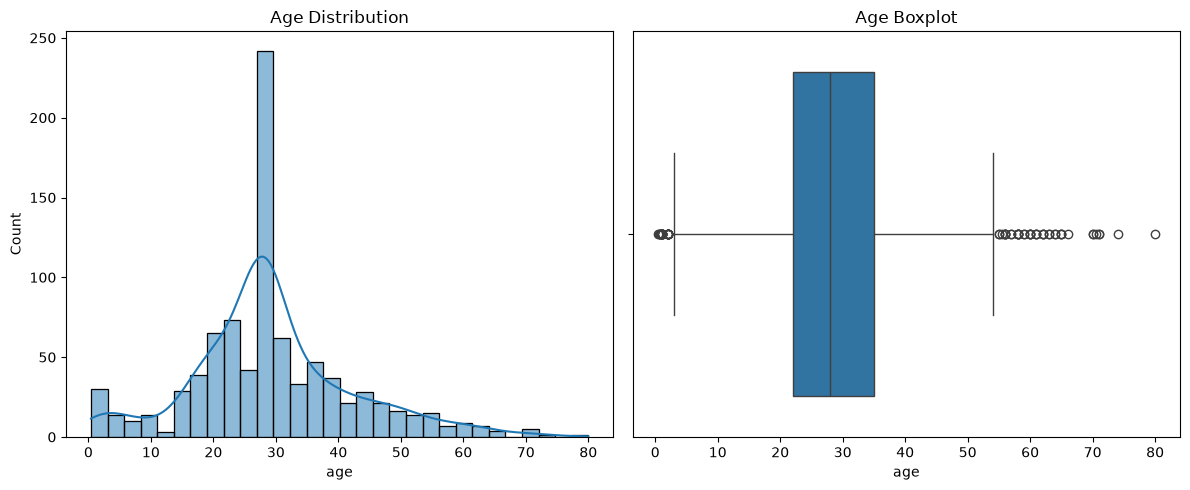

In [11]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_clean["age"], bins=30, kde=True)
plt.title("Age Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df_clean["age"])
plt.title("Age Boxplot")

plt.tight_layout()
plt.show()

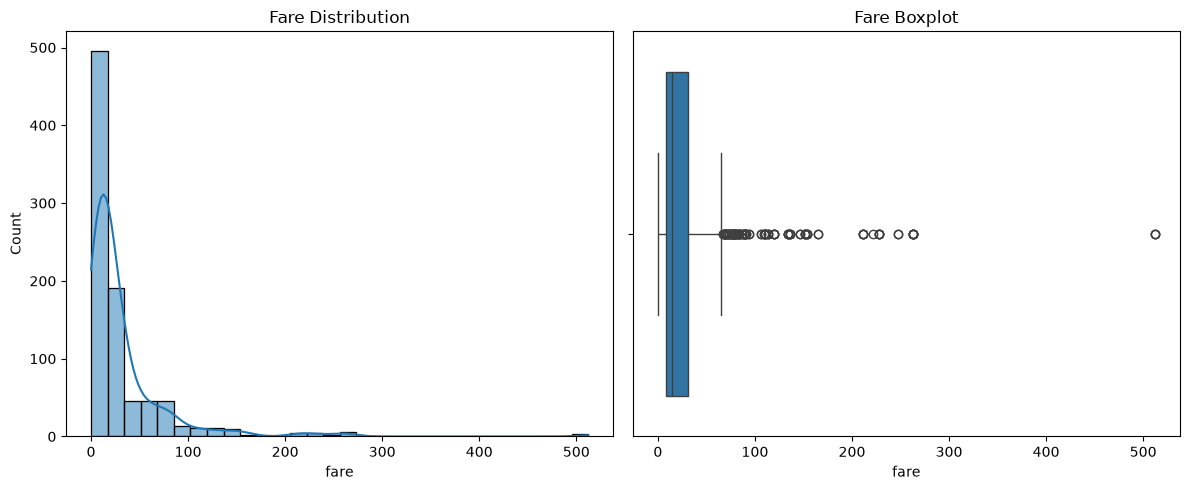

In [12]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_clean["fare"], bins=30, kde=True)
plt.title("Fare Distribution")

plt.subplot(1,2,2)
sns.boxplot(x=df_clean["fare"])
plt.title("Fare Boxplot")

plt.tight_layout()
plt.show()

In [13]:
def outlier_count(column):

    Q1 = df_clean[column].quantile(0.25)
    Q3 = df_clean[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df_clean[
        (df_clean[column] < lower) |
        (df_clean[column] > upper)
    ]

    return len(outliers)

print("Age Outliers :", outlier_count("age"))
print("Fare Outliers:", outlier_count("fare"))

Age Outliers : 65
Fare Outliers: 114


In [14]:
mean_fare = df_clean["fare"].mean()
median_fare = df_clean["fare"].median()
mode_fare = df_clean["fare"].mode()[0]

print("Mean   :", mean_fare)
print("Median :", median_fare)
print("Mode   :", mode_fare)

Mean   : 32.09668087739032
Median : 14.4542
Mode   : 8.05


In [15]:
if mean_fare > median_fare > mode_fare:
    print("Fare Distribution : Right Skewed")

elif mean_fare < median_fare < mode_fare:
    print("Fare Distribution : Left Skewed")

else:
    print("Fare Distribution : Approximately Symmetric")

Fare Distribution : Right Skewed


In [16]:
survival_by_sex = (
    df_clean.groupby("sex")["survived"]
    .mean()*100
)

print(survival_by_sex)

sex
female    74.038462
male      18.890815
Name: survived, dtype: float64


In [17]:
survival_by_class = (
    df_clean.groupby("pclass")["survived"]
    .mean()*100
)

print(survival_by_class)

pclass
1    62.616822
2    47.282609
3    24.236253
Name: survived, dtype: float64


In [18]:
survival_by_sex_class = (
    df_clean
    .groupby(["sex","pclass"])["survived"]
    .mean()*100
)

print(survival_by_sex_class)

sex     pclass
female  1         96.739130
        2         92.105263
        3         50.000000
male    1         36.885246
        2         15.740741
        3         13.544669
Name: survived, dtype: float64


In [19]:
male = df_clean[df_clean["sex"] == "male"]

female = df_clean[df_clean["sex"] == "female"]

print("Male Survival Rate")
print(male["survived"].mean()*100)

print()

print("Female Survival Rate")
print(female["survived"].mean()*100)

Male Survival Rate
18.890814558058924

Female Survival Rate
74.03846153846155


In [20]:
female_first = df_clean[
    (df_clean["sex"]=="female") &
    (df_clean["pclass"]==1)
]

male_third = df_clean[
    (df_clean["sex"]=="male") &
    (df_clean["pclass"]==3)
]

print("Female First Class Survival")
print(female_first["survived"].mean()*100)

print()

print("Male Third Class Survival")
print(male_third["survived"].mean()*100)

Female First Class Survival
96.73913043478261

Male Third Class Survival
13.544668587896252


In [21]:
corr_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr = df_clean[corr_columns].corr()

corr

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


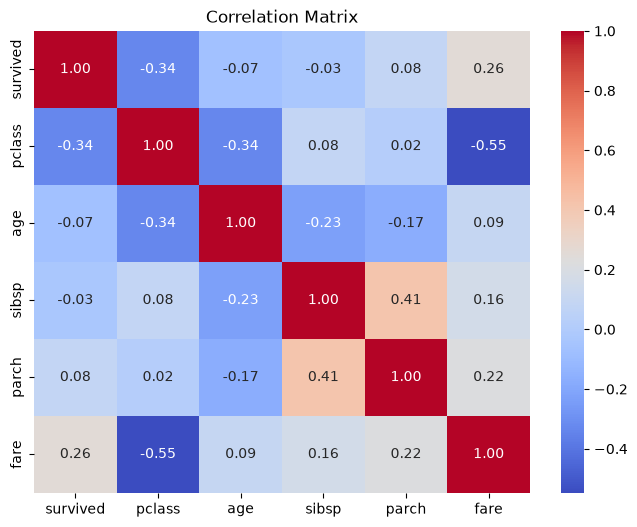

In [22]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

In [23]:
corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

corr_pairs = corr_pairs[corr_pairs < 1]

print(corr_pairs.drop_duplicates().head(2))

pclass  fare     0.548193
sibsp   parch    0.414542
dtype: float64


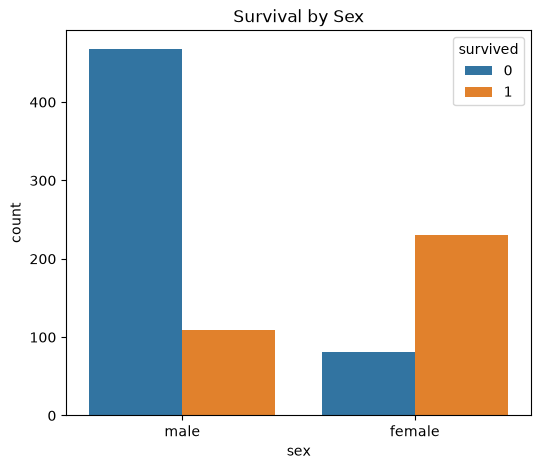

In [24]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df_clean,
    x="sex",
    hue="survived"
)

plt.title("Survival by Sex")

plt.show()

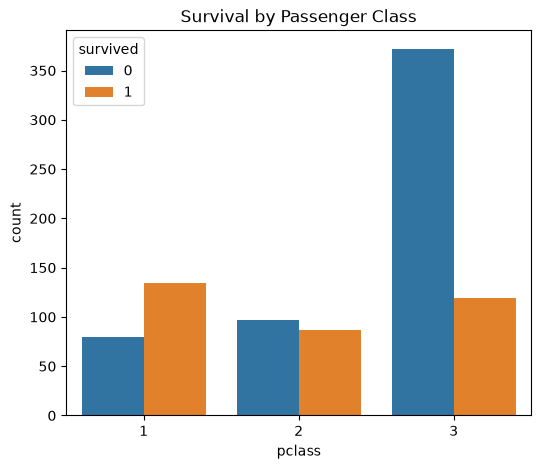

In [25]:
plt.figure(figsize=(6,5))

sns.countplot(
    data=df_clean,
    x="pclass",
    hue="survived"
)

plt.title("Survival by Passenger Class")

plt.show()

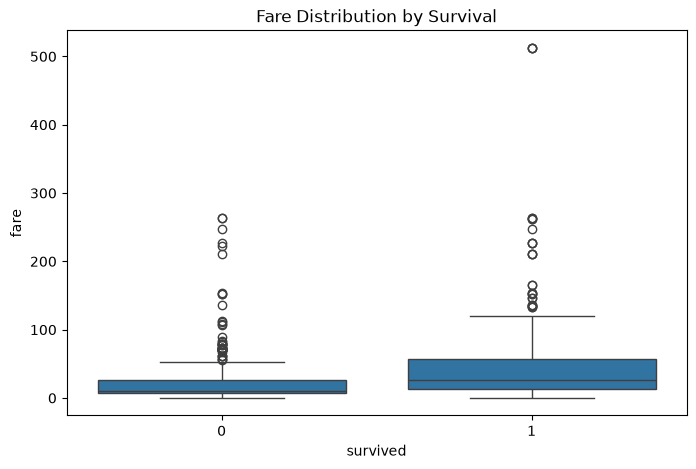

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="fare"
)

plt.title("Fare Distribution by Survival")

plt.show()

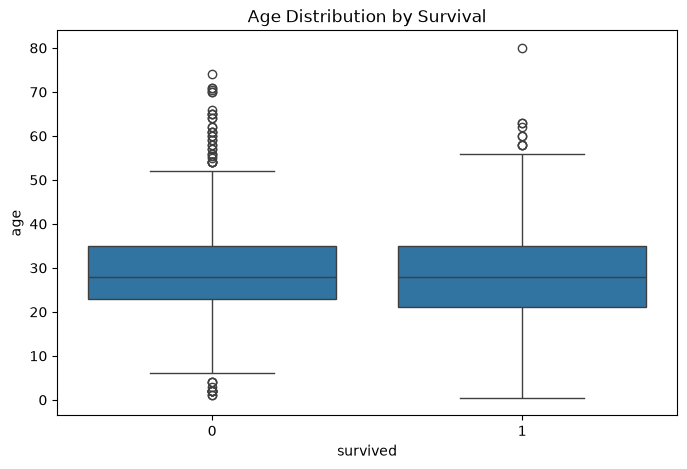

In [27]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df_clean,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")

plt.show()

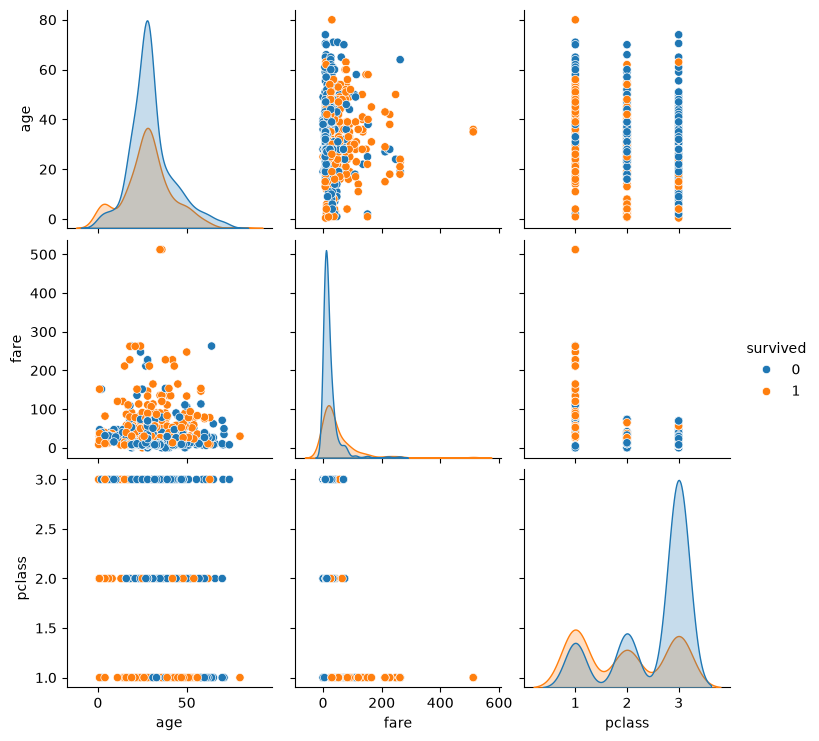

In [28]:
sns.pairplot(
    df_clean[
        [
            "survived",
            "age",
            "fare",
            "pclass"
        ]
    ],
    hue="survived"
)

plt.show()

In [29]:
print(df_clean[["age", "fare"]].describe())

              age        fare
count  889.000000  889.000000
mean    29.315152   32.096681
std     12.984932   49.697504
min      0.420000    0.000000
25%     22.000000    7.895800
50%     28.000000   14.454200
75%     35.000000   31.000000
max     80.000000  512.329200


In [30]:
scaler = StandardScaler()

scaled = scaler.fit_transform(
    df_clean[["age", "fare"]]
)

scaled_df = pd.DataFrame(
    scaled,
    columns=["age_scaled", "fare_scaled"]
)

scaled_df.head()

,age_scaled,fare_scaled
0,-0.563674,-0.500240
1,0.669217,0.788947
2,-0.255451,-0.486650
3,0.438050,0.422861
4,0.438050,-0.484133


In [31]:
print(scaled_df.describe())

         age_scaled   fare_scaled
count  8.890000e+02  8.890000e+02
mean   2.717486e-16  1.398706e-16
std    1.000563e+00  1.000563e+00
min   -2.226536e+00 -6.462044e-01
25%   -5.636741e-01 -4.872378e-01
50%   -1.013399e-01 -3.551972e-01
75%    4.380499e-01 -2.207954e-02
max    3.905556e+00  9.668551e+00


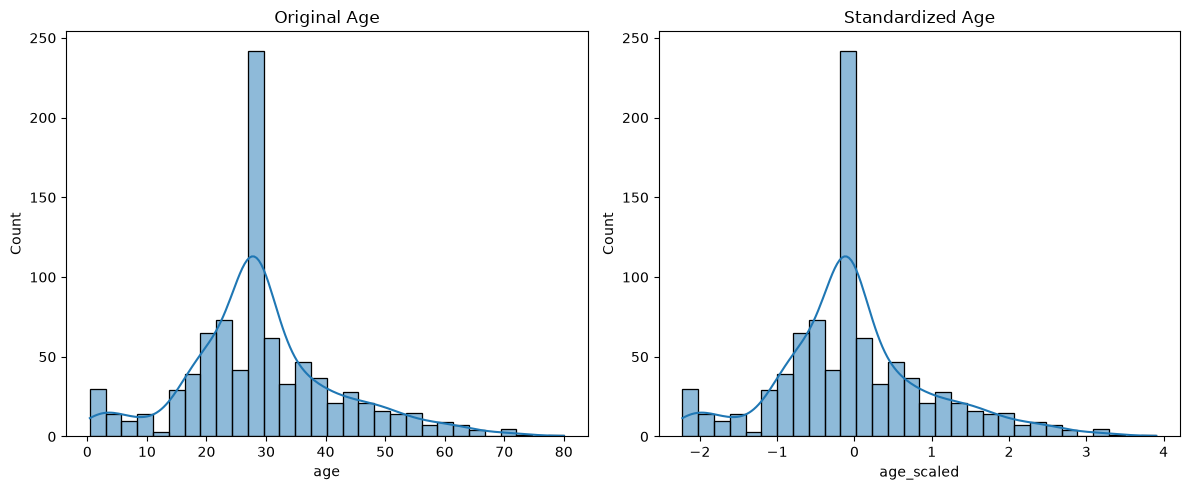

In [32]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    df_clean["age"],
    kde=True
)

plt.title("Original Age")

plt.subplot(1,2,2)

sns.histplot(
    scaled_df["age_scaled"],
    kde=True
)

plt.title("Standardized Age")

plt.tight_layout()

plt.show()

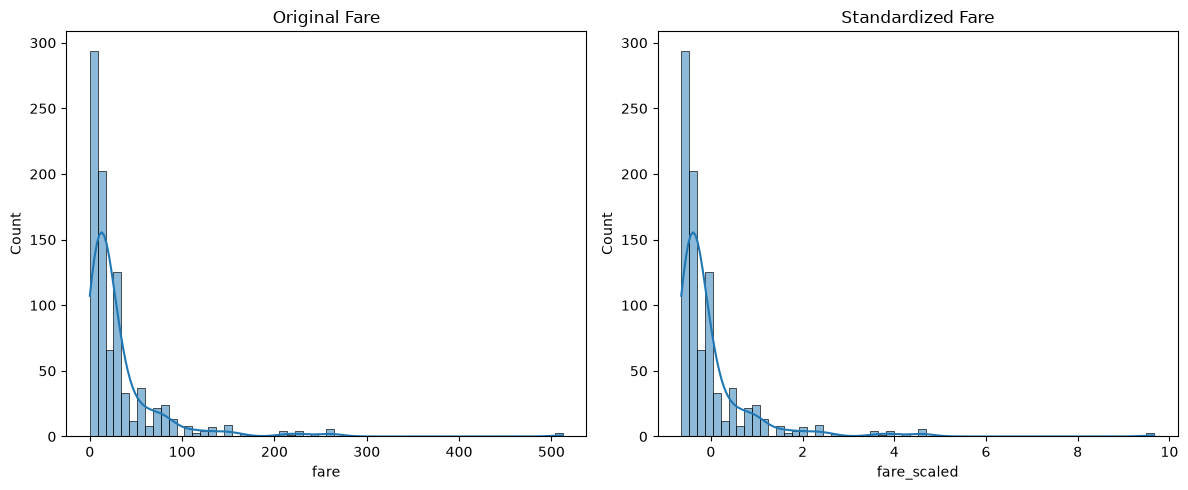

In [33]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)

sns.histplot(
    df_clean["fare"],
    kde=True
)

plt.title("Original Fare")

plt.subplot(1,2,2)

sns.histplot(
    scaled_df["fare_scaled"],
    kde=True
)

plt.title("Standardized Fare")

plt.tight_layout()

plt.show()

In [34]:
df_clean.to_csv("titanic.csv", index=False)

print("EDA Completed Successfully!")

EDA Completed Successfully!
